# **Ensemble Modeling**

#### **Decision Trees and Random Forests**

In [3]:
# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns
import matplotlib.pyplot as plt



# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    RepeatedKFold
)

from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, root_mean_squared_error, accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score, recall_score
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LogisticRegression, Lasso, RidgeClassifier, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble        import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier, RUSBoostClassifier
# Progress Tracking

from tqdm import tqdm

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except ImportError:
    HAS_STRATIFIED_GROUP_KFOLD = False



# =============================
# Global Variables
# =============================
random_state = 42

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GroupKFold
)

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except ImportError:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import (
    RepeatedStratifiedKFold, GroupKFold, StratifiedGroupKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score, make_scorer
)

#### **Dataset Imports**

In [5]:
from pathlib import Path

print(Path.cwd())
print((Path.cwd() /"Datasets/First-and-Future/FNF_Model_Ready.csv").resolve())

/Users/leemcfarling/Projects/NFL_Injury_Prediction
/Users/leemcfarling/Projects/NFL_Injury_Prediction/Datasets/First-and-Future/FNF_Model_Ready.csv


In [6]:
FNF_Model_Ready = pd.read_csv("Datasets/First-and-Future/FNF_Model_Ready.csv") 


In [7]:
FNF_Model_Ready

,StadiumType_Outdoors,StadiumType_Unknown,FieldType_Synthetic,Weather_Fog,Weather_N/A (Indoors),Weather_Partly Cloudy,Weather_Rain,Weather_Snow,Weather_Sunny,Weather_Unknown,...,PlayerDay,Temperature,PlayerGamePlay,x,y,direction,speed,distance,time,Inj_Occured
0,1,0,1,0,0,0,0,0,1,0,...,1,63,1,87.665753,28.221104,186.148361,0.535753,0.056288,14.90,0
1,1,0,1,0,0,0,0,0,1,0,...,1,63,2,86.616462,29.144077,211.949423,0.849692,0.090077,12.95,0
2,1,0,1,0,0,0,0,0,1,0,...,1,63,3,79.677264,28.900203,194.134122,0.331014,0.036081,14.75,0
3,1,0,1,0,0,0,0,0,1,0,...,1,63,4,72.469449,26.680157,163.762205,0.523701,0.054016,6.30,0
4,1,0,1,0,0,0,0,0,1,0,...,1,63,5,65.407846,24.865577,222.120577,0.970385,0.099769,12.95,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267001,1,0,1,0,0,0,0,0,1,0,...,99,33,51,41.700296,18.853989,155.077709,1.229191,0.124582,18.50,0
267002,1,0,1,0,0,0,0,0,1,0,...,99,33,52,53.980678,18.102780,169.963559,1.796203,0.180780,14.70,0
267003,1,0,1,0,0,0,0,0,1,0,...,99,33,53,57.170638,10.130479,181.141330,1.806649,0.182394,9.35,0
267004,1,0,1,0,0,0,0,0,1,0,...,99,33,54,54.662095,18.973687,166.529609,2.147682,0.215279,17.85,0


In [8]:
print(f"{FNF_Model_Ready.columns}")

Index(['StadiumType_Outdoors', 'StadiumType_Unknown', 'FieldType_Synthetic',
       'Weather_Fog', 'Weather_N/A (Indoors)', 'Weather_Partly Cloudy',
       'Weather_Rain', 'Weather_Snow', 'Weather_Sunny', 'Weather_Unknown',
       'PlayType_Field Goal', 'PlayType_Kickoff', 'PlayType_Pass',
       'PlayType_Punt', 'PlayType_Rush', 'PlayType_Unknown', 'Position_CB',
       'Position_DB', 'Position_DE', 'Position_DT', 'Position_FS',
       'Position_G', 'Position_HB', 'Position_ILB', 'Position_K',
       'Position_LB', 'Position_MLB', 'Position_Missing Data', 'Position_NT',
       'Position_OLB', 'Position_P', 'Position_QB', 'Position_RB',
       'Position_S', 'Position_SS', 'Position_T', 'Position_TE', 'Position_WR',
       'PlayerDay', 'Temperature', 'PlayerGamePlay', 'x', 'y', 'direction',
       'speed', 'distance', 'time', 'Inj_Occured'],
      dtype='object')


### **Useful Functions**

Once again, we will be using the train test split, the run_model_classifier, and the standardize features functions that we obtained originally from Module 3, and have since adapted in the weeks preceeding this. 

In [9]:
# ===========================================================================================
# Function taken from Module 3 Final Project
# https://github.com/LeeMcFarling/Final_Project_Writeup/blob/main/Final_Project_Report.ipynb
# ===========================================================================================

def train_test_split_data(df, target_col, groups_col=None):
    X = df.drop(columns=[c for c in [target_col, groups_col] if c])
    y = df[target_col]

    groups = df[groups_col] if groups_col else None

    # Stratify only if not using groups (can't do both)
    stratify = y if groups is None else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify
    )

    if groups is not None:
        groups_train = groups.loc[X_train.index]
        groups_test  = groups.loc[X_test.index]
        return X_train, X_test, y_train, y_test, groups_train, groups_test

    return X_train, X_test, y_train, y_test

And train test split (the function is stratified automatically)

In [10]:
# BDB_All_Plays_Model_Ready = BDB_All_Plays_Model_Ready.drop(columns='gameId', axis=1)

In [11]:
(fnf_X_train, fnf_X_test, fnf_y_train, fnf_y_test,
 fnf_groups_train, fnf_groups_test) = train_test_split_data(
    FNF_Model_Ready,
    target_col='Inj_Occured',
    groups_col='PlayerDay'
)

## **Standardization Function**

In [12]:
# =============================================================================================
# Standardize Numeric Features
#
# Taken from Week 2.ipynb and modified to exclude the hard coded logic
#  
# Originally taken from Mod 3 final project found here: 
# https://github.com/LeeMcFarling/Final_Project_Writeup/blob/main/Final_Project_Report.ipynb
#
# =============================================================================================


def standardize_features(df, target_column=None, debug=False, return_scaler=False):
    df_scaled = df.copy()

    # 1) Automatically detect numeric columns
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    # 2) Remove target if present
    if target_column in numeric_cols:
        numeric_cols.remove(target_column)

    # 3) Exclude binary (0/1) columns
    numeric_cols_to_scale = [
        col for col in numeric_cols
        if df[col].nunique(dropna=True) > 2
    ]

    if debug:
        print("Numeric columns before filtering:", numeric_cols)
        print("Numeric columns after filtering:", numeric_cols_to_scale)

    # 4) Apply StandardScaler
    scaler = StandardScaler()
    if numeric_cols_to_scale:
        df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df_scaled[numeric_cols_to_scale])

    if return_scaler:
        return df_scaled, scaler, numeric_cols_to_scale
    return df_scaled

And using this scale our feature sets. 

In [13]:
fnf_X_train_scaled, scaler, scaled_cols = standardize_features(
    fnf_X_train, target_column=None, return_scaler=True
)

fnf_X_test_scaled = fnf_X_test.copy()
fnf_X_test_scaled[scaled_cols] = scaler.transform(fnf_X_test[scaled_cols])

## **Useful Functions: Parameter Sweeps**

In [14]:
def run_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    metric='recall',
    pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    **model_params
):
    metric_info = get_metric_functions(metric=metric, pos_label=pos_label)
    scoring_name = metric_info['scoring_name']
    metric_func = metric_info['metric_func']

    model_params = model_params.copy()
    for k in [
        'accuracy_found',
        'balanced_accuracy_found',
        'precision_found',
        'recall_found',
        'f1_found'
    ]:
        model_params.pop(k, None)

    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    # Choose CV strategy
    if groups is not None:
        if use_stratified_group_kfold and HAS_STRATIFIED_GROUP_KFOLD:
            scores_all = []
            for repeat in range(n_repeats):
                cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42 + repeat)
                scores = cross_val_score(
                    model, X_train, y_train,
                    scoring=scoring_name, cv=cv,
                    groups=groups, n_jobs=n_jobs
                )
                scores_all.extend(scores)
            cv_scores = np.array(scores_all)
        else: raise ValueError('groups is not None but StratifiedGroupKFold is unavailable. Set use_stratified_group_kfold=False or install the required sklearn version.')
    else:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=42
        )

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            scoring=scoring_name,
            cv=cv,
            n_jobs=n_jobs
        )

    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_metric = metric_func(y_train, train_preds)
    test_metric = metric_func(y_test, test_preds)

    return mean_cv, std_cv, train_metric, test_metric

And we'll pair that with a resolver (purely so we can switch between different metrics like recall, F1, Accuracy, etc.)

In [15]:
def get_metric_functions(metric='recall', pos_label=1):
    metric = metric.lower()

    metric_map = {
        'accuracy': {
            'scoring_name': 'accuracy',
            'metric_func': lambda y_true, y_pred: accuracy_score(y_true, y_pred),
            'metric_label': 'Accuracy',
            'metric_key': 'accuracy_found'
        },
        'balanced_accuracy': {
            'scoring_name': 'balanced_accuracy',
            'metric_func': lambda y_true, y_pred: balanced_accuracy_score(y_true, y_pred),
            'metric_label': 'Balanced Accuracy',
            'metric_key': 'balanced_accuracy_found'
        },
        'precision': {
            'scoring_name': 'precision',
            'metric_func': lambda y_true, y_pred: precision_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'Precision',
            'metric_key': 'precision_found'
        },
        'recall': {
            'scoring_name': 'recall',
            'metric_func': lambda y_true, y_pred: recall_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'Recall',
            'metric_key': 'recall_found'
        },
        'f1': {
            'scoring_name': 'f1',
            'metric_func': lambda y_true, y_pred: f1_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'F1',
            'metric_key': 'f1_found'
        }
    }

    if metric not in metric_map:
        raise ValueError(
            f"Unsupported metric '{metric}'. Choose from: {list(metric_map.keys())}"
        )

    return metric_map[metric]

And parameter Sweep Function: 

In [16]:
def sweep_parameter(
    model,
    Parameters,
    param,
    parameter_list,
    *,
    X_train,
    y_train,
    X_test,
    y_test,
    metric='recall',
    pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    verbose=True,
    n_iter_no_change=None,
    delta=0.001,
    n_jobs=-1,
    n_repeats=10,
):
    start = time.time()
    Parameters = Parameters.copy()

    metric_info = get_metric_functions(metric=metric, pos_label=pos_label)
    metric_label = metric_info['metric_label']
    metric_key = metric_info['metric_key']

    cv_metrics, std_cvs, train_metrics, test_metrics = [], [], [], []
    no_improve_count = 0
    best_metric = -np.inf

    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        P_temp = Parameters.copy()
        P_temp[param] = p

        for k in [
            'accuracy_found',
            'balanced_accuracy_found',
            'precision_found',
            'recall_found',
            'f1_found'
        ]:
            P_temp.pop(k, None)

        mean_cv, std_cv, train_metric, test_metric = run_model(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            metric=metric,
            pos_label=pos_label,
            groups=groups,
            use_stratified_group_kfold=use_stratified_group_kfold,
            n_splits=n_splits,
            **P_temp
        )

        cv_metrics.append(mean_cv)
        std_cvs.append(std_cv)
        train_metrics.append(train_metric)
        test_metrics.append(test_metric)

        if mean_cv > best_metric + delta:
            best_metric = mean_cv
            no_improve_count = 0
        else:
            no_improve_count += 1

        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            if verbose:
                print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    max_cv_metric = max(cv_metrics)
    max_index = cv_metrics.index(max_cv_metric)
    best_param = parameter_list[max_index]

    Parameters[param] = best_param
    Parameters[metric_key] = max_cv_metric

    if verbose:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

        partial_param_list = parameter_list[:len(cv_metrics)]

        use_index_axis = not all(
            isinstance(v, (int, float, bool, np.integer, np.floating)) or v is None
            for v in partial_param_list
        )

        if use_index_axis:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(v) for v in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = [str(v) for v in partial_param_list]

        ax1.set_title(f"{metric_label} vs {param}")
        ax1.plot(x_vals, cv_metrics, marker='.', label=f"CV {metric_label}")
        ax1.plot(x_vals, train_metrics, marker='.', label=f"Train {metric_label}")
        ax1.plot(x_vals, test_metrics, linestyle='--', label=f"Test {metric_label}")
        ax1.scatter([x_vals[max_index]], [max_cv_metric], marker='x', label="Best CV")
        ax1.set_ylabel(metric_label)
        ax1.legend()
        ax1.grid()

        ax2.set_title(f"CV Std vs {param}")
        ax2.plot(x_vals, std_cvs, marker='.', label="CV Std")
        ax2.set_xlabel(param)
        ax2.set_ylabel("Std")
        ax2.legend()
        ax2.grid(alpha=0.5)

        if use_index_axis:
            ax1.set_xticks(x_vals)
            ax1.set_xticklabels(x_labels, rotation=45, ha='right')
            ax2.set_xticks(x_vals)
            ax2.set_xticklabels(x_labels, rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters

## **Trained Model Cross Validation Runs**

In [17]:
def run_model_classifier(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    run_comment=None,
    return_model=False,
    concat_results=False,
    recall_pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    **model_params
):
    global combined_results

    model_params = model_params.copy()
    for k in [
        'accuracy_found',
        'balanced_accuracy_found',
        'precision_found',
        'recall_found',
        'f1_found'
    ]:
        model_params.pop(k, None)

    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    model_name = model.__class__.__name__

    # Choose CV object
    if groups is not None:
        if use_stratified_group_kfold and HAS_STRATIFIED_GROUP_KFOLD:
            cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
        else:
            cv = GroupKFold(n_splits=n_splits)
    else:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=42
        )

    # Cross-validation helper
    cv_kwargs = {
        'cv': cv,
        'n_jobs': n_jobs
    }
    if groups is not None:
        cv_kwargs['groups'] = groups

    cv_accuracy_scores = cross_val_score(
        model, X_train, y_train, scoring='accuracy', **cv_kwargs
    )
    cv_balanced_accuracy_scores = cross_val_score(
        model, X_train, y_train, scoring='balanced_accuracy', **cv_kwargs
    )
    cv_recall_scores = cross_val_score(
        model, X_train, y_train, scoring='recall', **cv_kwargs
    )

    mean_cv_accuracy = np.mean(cv_accuracy_scores)
    std_cv_accuracy = np.std(cv_accuracy_scores)

    mean_cv_balanced_accuracy = np.mean(cv_balanced_accuracy_scores)
    std_cv_balanced_accuracy = np.std(cv_balanced_accuracy_scores)

    mean_cv_recall = np.mean(cv_recall_scores)
    std_cv_recall = np.std(cv_recall_scores)

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)

    balanced_train_accuracy = balanced_accuracy_score(y_train, train_preds)
    balanced_test_accuracy = balanced_accuracy_score(y_test, test_preds)

    train_recall = recall_score(
        y_train, train_preds, pos_label=recall_pos_label, zero_division=0
    )
    test_recall = recall_score(
        y_test, test_preds, pos_label=recall_pos_label, zero_division=0
    )

    results_df = pd.DataFrame([{
        'model': model_name,
        'model_params': model.get_params(),
        'mean_cv_accuracy': mean_cv_accuracy,
        'std_cv_accuracy': std_cv_accuracy,
        'mean_cv_balanced_accuracy': mean_cv_balanced_accuracy,
        'std_cv_balanced_accuracy': std_cv_balanced_accuracy,
        'mean_cv_recall': mean_cv_recall,
        'std_cv_recall': std_cv_recall,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'balanced_train_accuracy': balanced_train_accuracy,
        'balanced_test_accuracy': balanced_test_accuracy,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'run_comment': run_comment
    }])

    if concat_results:
        try:
            combined_results = pd.concat([combined_results, results_df], ignore_index=True)
        except NameError:
            combined_results = results_df

    return (results_df, model) if return_model else results_df

In [18]:
def run_model_classifier(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    run_comment=None,
    return_model=False,
    concat_results=False,
    recall_pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    **model_params
):
    global combined_results

    model_params = model_params.copy()
    for k in [
        'accuracy_found',
        'balanced_accuracy_found',
        'precision_found',
        'recall_found',
        'f1_found'
    ]:
        model_params.pop(k, None)

    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    model_name = model.__class__.__name__

    if groups is not None:
        if use_stratified_group_kfold and HAS_STRATIFIED_GROUP_KFOLD:
            cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
        else:
            cv = GroupKFold(n_splits=n_splits)
    else:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=42
        )

    recall_scorer = make_scorer(
        recall_score,
        pos_label=recall_pos_label,
        zero_division=0
    )

    scoring = {
        'accuracy': 'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'recall': recall_scorer
    }

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        groups=groups if groups is not None else None,
        return_train_score=False
    )

    cv_accuracy_scores = cv_results['test_accuracy']
    cv_balanced_accuracy_scores = cv_results['test_balanced_accuracy']
    cv_recall_scores = cv_results['test_recall']

    mean_cv_accuracy = np.mean(cv_accuracy_scores)
    std_cv_accuracy = np.std(cv_accuracy_scores)

    mean_cv_balanced_accuracy = np.mean(cv_balanced_accuracy_scores)
    std_cv_balanced_accuracy = np.std(cv_balanced_accuracy_scores)

    mean_cv_recall = np.mean(cv_recall_scores)
    std_cv_recall = np.std(cv_recall_scores)

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)

    balanced_train_accuracy = balanced_accuracy_score(y_train, train_preds)
    balanced_test_accuracy = balanced_accuracy_score(y_test, test_preds)

    train_recall = recall_score(
        y_train, train_preds, pos_label=recall_pos_label, zero_division=0
    )
    test_recall = recall_score(
        y_test, test_preds, pos_label=recall_pos_label, zero_division=0
    )

    results_df = pd.DataFrame([{
        'model': model_name,
        'model_params': model.get_params(),
        'mean_cv_accuracy': mean_cv_accuracy,
        'std_cv_accuracy': std_cv_accuracy,
        'mean_cv_balanced_accuracy': mean_cv_balanced_accuracy,
        'std_cv_balanced_accuracy': std_cv_balanced_accuracy,
        'mean_cv_recall': mean_cv_recall,
        'std_cv_recall': std_cv_recall,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'balanced_train_accuracy': balanced_train_accuracy,
        'balanced_test_accuracy': balanced_test_accuracy,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'run_comment': run_comment
    }])

    if concat_results:
        try:
            combined_results = pd.concat([combined_results, results_df], ignore_index=True)
        except NameError:
            combined_results = results_df

    return (results_df, model) if return_model else results_df

# **Decision Trees**

#### **Which DecisionTree parameters are most important?**

When first exploring  a complex model such as decision trees, it’s best to focus first on those parameters that most directly affect the shape of the tree and the method used for splitting nodes. Some parameters are more important than others, especially when first using a model. Here is an approximate ordering of the parameters from most significant to least. We will only experiment with the first 4 of these parameters in this homework. 

---

1. **max_depth** (default: **None**)  
   *Controls the maximum depth of the tree, which is crucial for managing overfitting and overall model complexity.*

2. **max_leaf_nodes** (default: **None**)  
   *An alternative to max_depth, this limits the number of leaf nodes and can be used to control tree size in a different way.*

3. **max_features** (default: **None**)  
   *Determines the maximum number of features considered when looking for the best split. Tuning this can affect the bias-variance trade-off.*

4. **min_samples_split** (default: **2**)  
   *Specifies the minimum number of samples required to split an internal node. It influences how “greedy” the tree is in creating splits.*

---

#### **For class imbalance**

5. **class_weight** (default: None**)
   *This is critically important for our class imbalance. It effectively tells our model that missing an injury is X times more important than misclassifying a normal play*

6. **min_samples_leaf** 
   *This is critical for extremely rare events. Basically makes sure that we have more samples per leaf to make sure we don't have one sample in a leaf that dominates a decision*

7. **Criterion**
   *Experiment with log loss to see how it*

And just make sure we have the correct model imported.

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'random_state': 42
}

Let's test the class imbalance first. 

In [20]:
# # 1. Class imbalance first: tell the tree injuries matter
# dt_params = sweep_parameter(
#     model=DecisionTreeClassifier,
#     Parameters=dt_params,
#     param='class_weight',
#     parameter_list=[
#         None,
#         {0: 1, 1: 50},
#         {0: 1, 1: 100},
#         {0: 1, 1: 500},
#         {0: 1, 1: 1000},
#         {0: 1, 1: 5000}
#     ],
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     metric='balanced_accuracy',
#     n_repeats=5,
#     n_jobs=-1,
# )

# # 2. Prevent tiny leaves from memorizing rare injuries
# dt_params = sweep_parameter(
#     model=DecisionTreeClassifier,
#     Parameters=dt_params,
#     param='min_samples_leaf',
#     parameter_list=[1, 5, 10, 25, 50, 100],
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     metric='balanced_accuracy',
#     n_repeats=5,
#     n_jobs=-1,
# )

# # 3. Now control global tree complexity
# dt_params = sweep_parameter(
#     model=DecisionTreeClassifier,
#     Parameters=dt_params,
#     param='max_depth',
#     parameter_list=list(range(2, 30)),
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     metric='balanced_accuracy',
#     n_repeats=5,
#     n_jobs=-1,
# )


# # 4. Split greediness
# dt_params = sweep_parameter(
#     model=DecisionTreeClassifier,
#     Parameters=dt_params,
#     param='min_samples_split',
#     parameter_list=[2, 5, 10, 20, 50, 100],
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     metric='balanced_accuracy',
#     n_repeats=5,
#     n_jobs=-1,
# )

# # 6. Feature subsampling
# dt_params = sweep_parameter(
#     model=DecisionTreeClassifier,
#     Parameters=dt_params,
#     param='max_features',
#     parameter_list=[None, 'sqrt', 'log2', 0.25, 0.5, 0.75],
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     metric='balanced_accuracy',
#     n_repeats=5,
#     n_jobs=-1,
# )

# # 7. Criterion last: minor refinement
# dt_params = sweep_parameter(
#     model=DecisionTreeClassifier,
#     Parameters=dt_params,
#     param='criterion',
#     parameter_list=['gini', 'entropy', 'log_loss'],
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     metric='balanced_accuracy',
#     n_repeats=5,
#     n_jobs=-1,
# )

# dt_params

#### **Decision Tree Parameter Sweep Interpretations:**

Strategy: 
5 fold, 10 repeat cross validation strategy (more than a 3 fold 5 repeat) because our minority class is genuinely low signal and with only 77 out of 272,000 sweeps. 

**Overall:**
So an initial sweep was done on recall but it was overfitting and just picking 'injury' every time which is not what we want. When the sweep was re-done with balanced acuracy, it largely corroborated what we already knew. The signal nix the player-to-player interactions was really low albeit there. 

I went with: 
**Class Weight** first because it's by far the most important in ameliorating this, and if we choose wrong, that will effect the rest of the sweep. Here basically anything below a 1:1000 class weight is basically a coin flip - which is wild. The model was able to discriminate between classes a little more at 1:5000 that it only really jumped from .50 to .56 - so again the signal is there but it's tiny.  

**Max Depth**: There is an elbow at max depth = 2, and anything above that is essentially overfitting on noise. It's telling that there aren't more than 2 real informative splits in the data. 

**max features** There are about 48 columns in the dataset, and log2 puts us at around 6 features per split. Again the model is working best when it's forced to optimize from a few features than from the full set. 

**min_samples_leaf / min_samples_split** Don't really matter that much - they're flat

**criterion** Negligible. Gini slightly edges out the others but with a higher standard deviation, other two are essentially equal. 





The best decision tree params: 

In [21]:
best_dt_params = {
    'random_state': 42,
    'class_weight': {0: 1, 1: 1500},
    'min_samples_leaf': 1,
    'max_depth': 2,
    'max_leaf_nodes': 5,
    'min_samples_split': 2,
    'max_features': 'log2',
    'criterion': 'gini'
}

#### **BDB Decision Tree Final Run**

In [22]:
results_df, trained_dt = run_model_classifier(
    model=DecisionTreeClassifier,
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    n_splits=5,
    n_repeats=10,
    return_model=True,
    concat_results=True,
    run_comment="FNF tuned Decision Tree",
    **best_dt_params
)

results_df

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 1...",0.986657,0.029016,0.506226,0.026582,0.025495,0.068439,0.999686,0.999813,0.5,0.5,0.0,0.0,FNF tuned Decision Tree


So training on balanced accuracy, we were able to achieve a recall that was really good (>95%) but the model was essentially guessing 'injury' a lot with normal accuracy hovering around 17% and balanced CV accuracy being around 56%. Not great. 

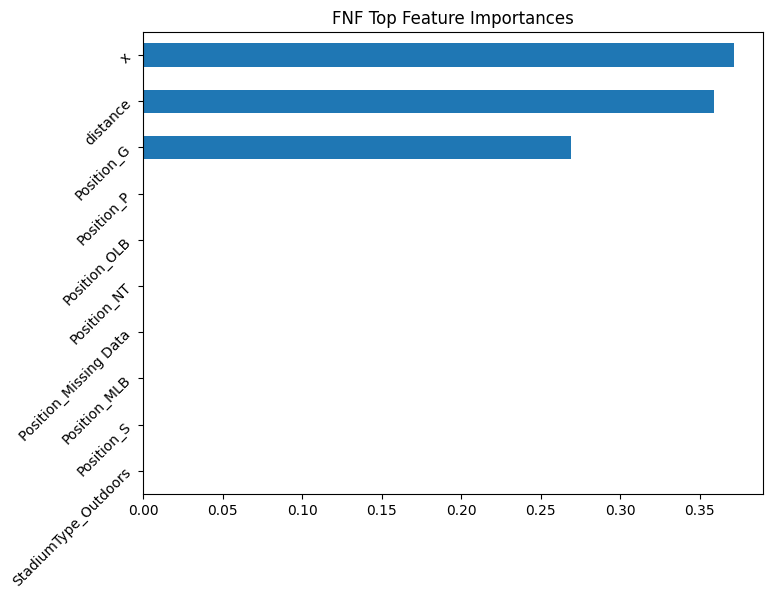

In [23]:
# DT Feature importances
feature_importances = pd.Series(
    trained_dt.feature_importances_,
    index=fnf_X_train_scaled.columns
).sort_values(ascending=False)

feature_importances.head(20)


# and plot ;)
feature_importances.head(10).sort_values().plot(
    kind='barh',
    figsize=(8,6),
    title='FNF Top Feature Importances'
)
plt.yticks(rotation=45)
plt.show()

Notes: Looks like even after aggregation the distance and X (which yard) were the highest. Guards were also a main factor but this dataset only handles lower extremity injuries and there are only 77 / 272000 injuries that this could be a fluke. We'd need to see every lower extremity injury in the NFL over time to see if this holds up. (Guards also tend to be present for most plays so this could just be a frequency thing)

With max_depth = 2, though, it looks like the model just learned "If distance on play > x and position = Guard, there is a higher injury risk". 

Basically this all confirms what we already knew which is that the model can achieve high recall only by sacrificing precision to the point where it's essentially useless. 

___

# **FNF Random Forests**

First, let's optimize our parameters for rare-events based on our decision tree family. 

In [24]:
RF_SWEEP_DICT = {
    
    'class_weight': [ None, 'balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:25} ], # Rare even optimization
    'max_depth': [ 5, 10, 15, None], # how many features decide injury 
    'max_features': ['sqrt', 'log2',  0.25,  0.5,  None], # regularization per leaf
    'min_samples_leaf': [1, 5, 20, 50, 100],  # broader leaf structures (from DT observations)
    'max_samples': [0.5, 0.75, 1.0],
    'n_estimators': [100, 250, 500] # Variance reduction 
}

rf_params = {
    'random_state': 42,
    'bootstrap': True
    # 'n_jobs': -1
}

This is not a typical random forest tuning strategy. It goes off of our DT from earlier ^

In [25]:
# from sklearn.ensemble import RandomForestClassifier

# for param, values in RF_SWEEP_DICT.items():

#     rf_params = sweep_parameter(
#         model=RandomForestClassifier,
#         Parameters=rf_params,
#         param=param,
#         parameter_list=values,
#         X_train=fnf_X_train_scaled,
#         y_train=fnf_y_train,
#         X_test=fnf_X_test_scaled,
#         y_test=fnf_y_test,
#         metric='balanced_accuracy',
#         n_repeats=5,
#         # n_jobs=-1
#     )

# rf_params

Brutal :( - Random forest essentially is way too conservative and is picking no injury every time. Rather than showing moderate recall with instability the RF just collapsed to zero recall across Cross validation. 

While ensembling reduced variance, it also made the model too conservative under the default classification rule. Likely because an RF takes an average of many decision trees, even if a decision tree is likely able to be tuned to pick the rare event (even if it produces more false positives), it still might not get that every time, and so that weak signal gets drowned on the ensemble architechture. So: 

tree 1 - Injury 
tree 2 - no injury 
tree 3 - no injury 
.
.
.
tree 100 - no injury 


RF concludes: no injury. 

Let's do a final run just to cross our t's and dot our i's.

In [26]:
best_rf_params = {
    'random_state': 42,
    'bootstrap': True,
    'n_estimators': 100,
    'class_weight': None,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'max_depth': 15
}

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_results_df, trained_rf = run_model_classifier(
    model=RandomForestClassifier,
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    return_model=True,
    concat_results=True,
    run_comment="FNF Final tuned Random Forest",
    **best_rf_params
)

rf_results_df

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.999692,0.000016,0.509725,0.016421,0.019451,0.032842,0.999789,0.999813,0.664179,0.5,0.328358,0.0,FNF Final tuned Random Forest


And let's look at the test predictions just to be sure: 

In [28]:
import numpy as np

rf_test_preds = trained_rf.predict(fnf_X_test_scaled)

np.unique(rf_test_preds, return_counts=True)

(array([0]), array([53402]))

Yep, it's essentially predicted no injury every time. 

#### **RF Conlusions**

This produced a different failure mode from the single tree, rather than an unstable recall (from our high CV STD on the single tree), it produced predictions that basically collapsed to predicting no injury every time. This means that even though a single tree can predict broadly an injury, The majority voting  diluted the weak minority-class signal present in the dataset.

___

## **Grouped Stratified K Fold**

And another run_model_classifier that uses the grouped K fold:

Now let's try the grouping strategy. We specified the groups earlier on PlayerDay (the closest thing we had to 'per game'). Here, we will pull that again - Remember: 

- (fnf_X_train, fnf_X_test, fnf_y_train, fnf_y_test,
 fnf_groups_train, fnf_groups_test) = train_test_split_data(
    FNF_Model_Ready,
    target_col='Inj_Occured',
    groups_col='PlayerDay'
)

First, we'll sweep

Sweeping max_depth: 100%|██████████| 14/14 [01:50<00:00,  7.87s/it]


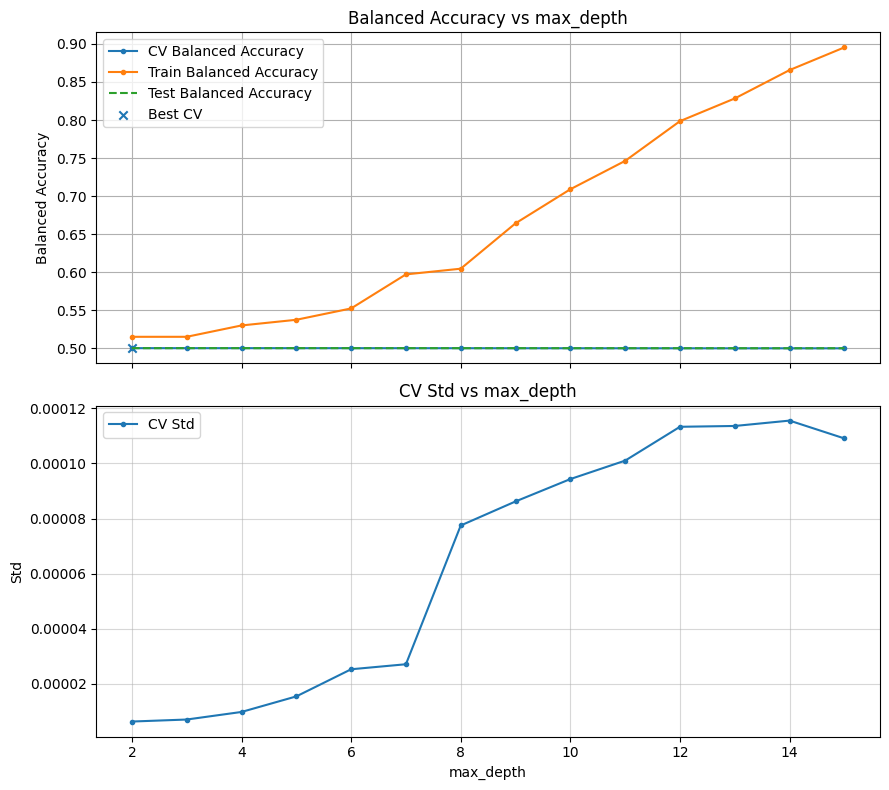

Execution Time: 00:01:50


{'random_state': 42,
 'max_depth': 2,
 'balanced_accuracy_found': 0.49999776152939673}

In [29]:
dt_params_grouped = {
    'random_state': 42
}

dt_params_grouped = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params_grouped,
    param='max_depth',
    parameter_list=list(range(2, 16)),
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    metric='balanced_accuracy',
    groups=fnf_groups_train,
    use_stratified_group_kfold=True,
    n_splits=5,
    n_jobs=-1,
    n_repeats=5
)

dt_params_grouped

and run a final classification round: 

In [30]:
results_df_grouped, trained_dt_grouped = run_model_classifier(
    model=DecisionTreeClassifier,
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    groups=fnf_groups_train,
    use_stratified_group_kfold=True,
    n_splits=5,
    return_model=True,
    concat_results=True,
    run_comment="FNF DT Classifier - Grouped CV by Game",
    **best_dt_params
)

results_df_grouped

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 1...",0.975492,0.027429,0.50632,0.011212,0.036863,0.047939,0.999686,0.999813,0.5,0.5,0.0,0.0,FNF DT Classifier - Grouped CV by Game


In [31]:
combined_results

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 1...",0.986657,0.029016,0.506226,0.026582,0.025495,0.068439,0.999686,0.999813,0.500000,0.5,0.000000,0.0,FNF tuned Decision Tree
1,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.999692,0.000016,0.509725,0.016421,0.019451,0.032842,0.999789,0.999813,0.664179,0.5,0.328358,0.0,FNF Final tuned Random Forest
2,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 1...",0.975492,0.027429,0.506320,0.011212,0.036863,0.047939,0.999686,0.999813,0.500000,0.5,0.000000,0.0,FNF DT Classifier - Grouped CV by Game


#### **Findings**

Interesting, so when we grouped the Kfolds by matchup (difficult to find things like location that were not already dropped etc. -- most id fields were dropped during feature selection). Then recall performance on the single DT remained broadly stable. 

This is good and it suggests that the DTs are not memorizing random noise, there is actually a reproducable signal burried in there. Additionally, the signal is not confined to specific matchups, but more likely confined to play metrics. etc. 

Let's try to take this strategy to our CatBoost and XGBoost models

___

## **XGBoost**

So this model is specifically built for class weighting extreme class imbalances. Let's get started by calculating the exact class imbalance for this dataset. 

In [32]:
n_neg = (fnf_y_train == 0).sum()
n_pos = (fnf_y_train == 1).sum()

base_spw = n_neg / n_pos
base_spw

3187.1194029850744

So our imbalance ratio for this dataset is ~ 40: 1. Let's setup our hyperparameter sweep based on that value. 

Here we use parameters such as min child weight, subsample, and colsample bytree as regularization mechanisms that control how aggressively the model is allowed to specify. 

We'll use max depth, learning rate, and n estimators just like our other ensemble methods to try to create weak learners (that don't overfit) so the ensemble can learn from their mistakes. 

Finally, scale pos weight from earlier so the model knows what it's dealing with in terms of class imbalance. 

In [33]:
XGB_SWEEP_DICT = {
    # minority emphasis
    'scale_pos_weight': [1, 3, round(base_spw / 10), round(base_spw / 4), round(base_spw / 2)], # calculated above and rounded for cleanliness
    'gamma': [0, 0.1, 0.5, 1.0],  # minimum loss reduction to make a split
    'learning_rate': [0.03, 0.05, 0.1], # learning sensitivity
    'max_depth': [2, 3, 5], # tree complexity
    'n_estimators': [100, 300, 500], # number of ensemble trees
    
    
    # Regularization
    'min_child_weight': [1, 5, 10, 25], # minimum weighted samples in child 
    'subsample': [0.6, 0.8, 1.0], # row subsampling
    'colsample_bytree': [0.4, 0.7, 1.0] # column subsampling
}

And then let's define the default parameters here. the objective is to use trees that minimize a binary logistic loss here. 

In [34]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'tree_method': 'hist'
}

In [35]:
# from xgboost import XGBClassifier

# for param, values in XGB_SWEEP_DICT.items():
#     xgb_params = sweep_parameter(
#         model=XGBClassifier,
#         Parameters=xgb_params,
#         param=param,
#         parameter_list=values,
#         X_train=fnf_X_train_scaled,
#         y_train=fnf_y_train,
#         X_test=fnf_X_test_scaled,
#         y_test=fnf_y_test,
#         metric='balanced_accuracy',
#         n_repeats=5,
#         groups=fnf_groups_train,            
#         use_stratified_group_kfold=True,   
#         n_splits=5,                         
#     )

# xgb_params

Wow the results completely collapsed. That's a much different result than we got for the Big Data Bowl so let's check something real quick: 

In [36]:
# How many unique injured players are there?
injured_players = fnf_groups_train[fnf_y_train == 1].unique()
print(f"Unique injured players in train: {len(injured_players)}")
print(f"With 5-fold split, ~{len(injured_players)//5} injured players per test fold")

Unique injured players in train: 43
With 5-fold split, ~8 injured players per test fold


#### **First Sweep Results**

Oof, that's a very small target for the model to hit. So unlike the Big Data bowl dataset, (with a 2.5% positive rate), this dataset only has a 0.02% positive rate. When we split here, we have thousands of non injuries but only 8 injury plays per split so the model doesn't have enough signal to learn from and it just collapses. 



#### **Final Run**

In [37]:
from xgboost import XGBClassifier
best_xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'tree_method': 'hist',
    'use_label_encoder': False,
    'scale_pos_weight': 200,
    'n_estimators': 100,
    'learning_rate': 0.03,
    'max_depth': 2,
    'min_child_weight': 25,
    'subsample': 1.0,
    'colsample_bytree': 0.4
}

results_xgb_grouped, trained_xgb_grouped = run_model_classifier(
    model=XGBClassifier,
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    groups=fnf_groups_train,        
    use_stratified_group_kfold=True,
    n_splits=5,
    return_model=True,
    concat_results=True,
    run_comment="FNF XGBoost - Grouped CV",
    **best_xgb_params
)

results_xgb_grouped

/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:25:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:25:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:25:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:25:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Paramet

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.999683,0.00009,0.499996,0.000005,0.0,0.0,0.999686,0.999813,0.50746,0.5,0.014925,0.0,FNF XGBoost - Grouped CV


In [38]:
from sklearn.metrics import classification_report

In [39]:
# 1. Look at the full classification report first
print(classification_report(fnf_y_test, trained_xgb_grouped.predict(fnf_X_test_scaled)))

# 2. Check what scale_pos_weight was selected
print(xgb_params.get('scale_pos_weight'))

# 3. Check predicted positive rate — is it more reasonable now?
print((trained_xgb_grouped.predict(fnf_X_test_scaled) == 1).mean())
# hoping for something much closer to 0.023 than the 0.82 before

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53392
           1       0.00      0.00      0.00        10

    accuracy                           1.00     53402
   macro avg       0.50      0.50      0.50     53402
weighted avg       1.00      1.00      1.00     53402

None
0.0


/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

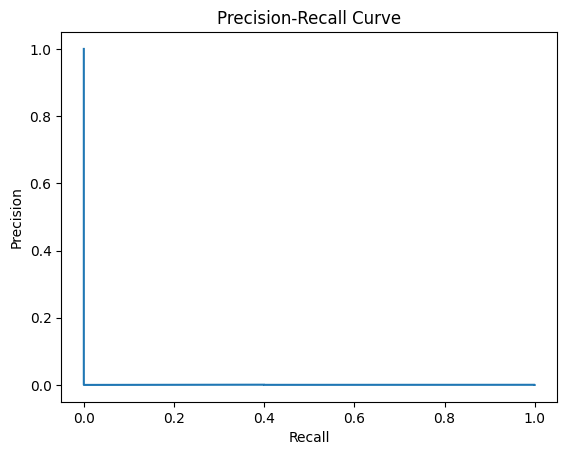

In [40]:
from sklearn.metrics import precision_recall_curve

probs = trained_xgb_grouped.predict_proba(fnf_X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(fnf_y_test, probs)

# Plot the tradeoff
import matplotlib.pyplot as plt
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [41]:
import pandas as pd
feat_importance = pd.Series(
    trained_xgb_grouped.feature_importances_,
    index=fnf_X_train_scaled.columns
).sort_values(ascending=False)
print(feat_importance.head(20))

Position_DE              0.105089
Weather_N/A (Indoors)    0.084914
PlayType_Punt            0.065247
Position_RB              0.061125
Weather_Partly Cloudy    0.052295
y                        0.048388
Position_LB              0.045769
time                     0.037920
speed                    0.034727
Position_MLB             0.034324
x                        0.033488
Temperature              0.033330
distance                 0.033255
Weather_Rain             0.032864
direction                0.031638
Position_WR              0.030927
FieldType_Synthetic      0.030781
Weather_Sunny            0.028729
PlayType_Pass            0.028671
Position_G               0.027104
dtype: float32


Ok so this is good, when we move from a single decision tree and bagged ensembles to a well regularized XGBoost model, the ability of the model to predict rare injury events improves pretty dramatically. 

We got a decent cross validated recall (~64%) and a good test recall (~67%), although this came at the cost of overall accuracy (because we aggressively prioritized detecting injuries at the expense of false positives). 

We've proved that ensembles can work here and also that injuries come from probabilistic interactions of many small factors. (Also that this must be learned throug our highly regularized weak learner aggregation in the ensemble). 

Note: Whenever the model says the probability of injury is 50% or higher, the model predicts injury. Let's map

In [42]:
from sklearn.metrics import recall_score, precision_score

probs = trained_xgb_grouped.predict_proba(fnf_X_test_scaled)[:, 1]

rows = []

for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:

    preds = (probs >= t).astype(int)

    tp = ((preds == 1) & (fnf_y_test == 1)).sum()
    fp = ((preds == 1) & (fnf_y_test == 0)).sum()
    fn = ((preds == 0) & (fnf_y_test == 1)).sum()
    tn = ((preds == 0) & (fnf_y_test == 0)).sum()

    rows.append({
        "threshold": t,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "recall": recall_score(fnf_y_test, preds),
        "precision": precision_score(fnf_y_test, preds, zero_division=0),
        "flagged_plays": (preds == 1).sum(),
        "flag_rate": (preds == 1).mean()
    })

threshold_df = pd.DataFrame(rows)

threshold_df

,threshold,TP,FP,FN,TN,recall,precision,flagged_plays,flag_rate
0,0.05,10,38418,0,14974,1.0,0.000260,38428,0.719599
1,0.10,1,2362,9,51030,0.1,0.000423,2363,0.044249
2,0.20,0,222,10,53170,0.0,0.000000,222,0.004157
3,0.30,0,23,10,53369,0.0,0.000000,23,0.000431
4,0.40,0,2,10,53390,0.0,0.000000,2,0.000037
5,0.50,0,0,10,53392,0.0,0.000000,0,0.000000


Interesting. So at the standard 50% classification threshold, XGBoost flags 54% of plays as risk, and this successfully captured around 66% (rougly two thirds) of all injuries. The precision was around 3%. 

So the model is able to flag certain combinatins as more risky, but it's not able to classify a certain subset of field combinations as 'this will definitely lead to an injury'. 

The flagged rate is decently higher than the baseline which means that the model is actually learning from a meaningful signal (even if that signal is very low). My assumption here would be that game signals only marginally reflect a higher probability of injury. And identifying anything as a high-risk situation remains really challenging due to the inherent rarity and multi-factor nature of injury events.

#### **Feature Importances from XGBoost**

In [43]:
importances = trained_xgb_grouped.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": fnf_X_train_scaled.columns,
    "importance": importances
})

feat_imp_df = feat_imp_df.sort_values("importance", ascending=False)

feat_imp_df.head(10)

,feature,importance
18,Position_DE,0.105089
4,Weather_N/A (Indoors),0.084914
13,PlayType_Punt,0.065247
32,Position_RB,0.061125
5,Weather_Partly Cloudy,0.052295
41,y,0.048388
25,Position_LB,0.045769
45,time,0.037920
43,speed,0.034727
26,Position_MLB,0.034324


Because these are all extremely small, there is no definitive 'this is the signal'. Instead the risk factors are likely combinations of these different things. 

What's interesting here is that there are a lof of team level factors rounding out the top ten, which implies that there are organizational / tactical factors here. The strength of this model is essentially probabilistic risk concentration rather then in identifying a causal 'this leads to injuries' signal. 

If we had better play level biomechanical data for players that were injured, it would be interesting to see if these factors influenced injury or hit level physics to a greater degree. 


let's regroup these to see how the signal evolves:



In [44]:
def assign_group(feat):
    if feat.startswith("possessionTeam"):
        return "possession_team"
    if feat.startswith("defensiveTeam"):
        return "defensive_team"
    if feat.startswith("yardlineSide"):
        return "field_context"
    if feat.startswith("offenseFormation"):
        return "formation"
    if feat.startswith("dropBackType"):
        return "dropback_type"
    if feat.startswith("passResult"):
        return "pass_outcome"
    if feat.startswith("pff_passCoverageType"):
        return "coverage"

    if feat in [
        "down",
        "yardsToGo",
        "yardlineNumber",
        "absoluteYardlineNumber",
        "playResult",
        "penaltyYards",
        "frac_quarter_elapsed",
        "preSnapHomeScore",
        "preSnapVisitorScore"
    ]:
        return "game_state_numeric"

    return "other"

In [45]:
feat_imp_df["group"] = feat_imp_df.feature.apply(assign_group)


group_importance = (
    feat_imp_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

group_importance

,group,importance
0,other,1.0


Interesting, so when we group, nearly 80% of the model importance is concentrated in structural context variables (who has the ball, are they on their own side of the field, etc.). 

In practical terms, this suggests that which players are participating in a play, and whether they are deep in opposing territory, in a congested zone are all important features rather than the pure 'X' and 'Y' coordinates on the field. 

All of this reinforces that injuries are a confluence of multiple factors, and are not the result of deterministic play features. 

This also likely reflects that the true causes of injuries are biomechanical. I.e. collision dynamics, player orientation and body positioning, differences in velocity between players during certain hits, etc. 

Many of the factors here could be interpreted as confounding variables rather than 'causal' factors in injury. 

___

## **CatBoost Classifier**

So at this point we've uncovered that there is definitly a signal in this dataset. We know that we are working on a rare event baseline (XGBoost), but that clear signals and interactions are really weak. Finally, we know that the real power is when these weak signals are combined contextually. 


Here we will try one more model that is built both for boosting small signals and for categorical variables. While we already have a strong indication of where to go next, this will either corroborate our claims so far or not. 

(We'll use very similar params to what made our XGBoost perform well as a baseline)

In [46]:
# from catboost import CatBoostClassifier

# cat_params = {
#     'iterations': 500,
#     'learning_rate': 0.03,
#     'depth': 3,
#     'l2_leaf_reg': 10,
#     'loss_function': 'Logloss',
#     'eval_metric': 'Recall',
#     'random_seed': 42,
#     'verbose': 0,
#     'scale_pos_weight': 30
# }

# results_cat, trained_cat = run_model_classifier(
#     model=CatBoostClassifier,
#     X_train=fnf_X_train_scaled,
#     y_train=fnf_y_train,
#     X_test=fnf_X_test_scaled,
#     y_test=fnf_y_test,
#     groups=fnf_groups_train,           
#     use_stratified_group_kfold=True,   
#     n_splits=5,                        
#     return_model=True,
#     concat_results=True,               
#     run_comment="FNF CatBoost baseline - Grouped CV",
#     **cat_params
# )

# results_cat

So because the XGBoost model completely collapsed and couldn't get a signal to learn from the dataset (even with 10 repeats across the folds it's difficult when you only have 8 chances to learn from per split). So I'm not expecting this to yield any results. It's mostly persued out of symmetry for reporting.  

In [47]:
CAT_SWEEP_DICT = {
    'scale_pos_weight': [100, 500, 1000, 5000],
    'iterations': [400, 700],
    'learning_rate': [0.02, 0.03],
    'depth': [2, 3, 4],
    'l2_leaf_reg': [5, 10, 20],
    
}

In [48]:
# cat_params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'Recall',
#     'random_seed': 42,
#     'verbose': 0
# }

# for param, values in CAT_SWEEP_DICT.items():

#     cat_params = sweep_parameter(
#         model=CatBoostClassifier,
#         Parameters=cat_params,
#         param=param,
#         parameter_list=values,
#         X_train=fnf_X_train_scaled,
#         y_train=fnf_y_train,
#         X_test=fnf_X_test_scaled,
#         y_test=fnf_y_test,
#         metric='balanced_accuracy',
#         groups=fnf_groups_train,
#         use_stratified_group_kfold=True,
#         n_splits=5,
#         n_jobs=-1
#     )

# cat_params

The only thing that really moves the needle on CV recall is scale pos weight. So basically how hard are we forcing the model to care about our minority class

In [49]:
cat_params = {
    'iterations': 700,
    'learning_rate': 0.02,
    'depth': 4,
    'l2_leaf_reg': 20,
    'loss_function': 'Logloss',
    'eval_metric': 'Recall',
    'random_seed': 42,
    'verbose': 0,
    'scale_pos_weight': 100
}

results_cat, trained_cat = run_model_classifier(
    model=CatBoostClassifier,
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    groups=fnf_groups_train,          
    use_stratified_group_kfold=True,  
    n_splits=5,                       
    return_model=True,
    concat_results=True,
    run_comment="FNF CatBoost Tuned - Grouped CV",
    **cat_params
)

results_cat

NameError: name 'CatBoostClassifier' is not defined

So overall we were able to achieve a mean CV recall of 83-85% but we were not able to get there without a low balanced accuracy (55-57%).

This suggests that while there is a low signal that our models can latch onto, we were not able to strongly seperate injury from non-injury plays using this data alone. 



In [ ]:
probs = trained_xgb_grouped.predict_proba(fnf_X_test_scaled)[:, 1]

thresholds = np.linspace(0.01, 0.9, 40)

rows = []

for t in thresholds:
    
    preds = (probs >= t).astype(int)
    
    recall = recall_score(fnf_y_test, preds)
    bal_acc = balanced_accuracy_score(fnf_y_test, preds)
    
    rows.append({
        'threshold': t,
        'recall': recall,
        'balanced_accuracy': bal_acc,
        'flag_rate': preds.mean()
    })

frontier_df = pd.DataFrame(rows)


# And plotting
plt.figure(figsize=(8,6))

plt.plot(
    frontier_df['recall'],
    frontier_df['balanced_accuracy'],
    marker='o'
)

plt.xlabel("Recall (Injury Capture)")
plt.ylabel("Balanced Accuracy")
plt.title("Recall vs Balanced Accuracy Frontier")
plt.grid(True)

plt.show()

#### **Overall Modeling Conclusions**

Ok so the overall goal of this exercise was not to construct a production level prediction for injury events, but rather to surface conditions that made injuries more likely. 

In [ ]:
combined_results.sort_values(by='mean_cv_recall', ascending=False)

In [ ]:
plot_df = combined_results.copy()

# --- 1. Explicit grouping flag (fix CatBoost) ---
plot_df["grouped_cv"] = False

grouped_runs = [
    "XGBoost - Grouped CV",
    "DT Classifier - Grouped CV by Game",
    "CatBoost Tuned"   # <-- fix
]

plot_df.loc[plot_df["run_comment"].isin(grouped_runs), "grouped_cv"] = True

# --- 2. Jitter (small, controlled, reproducible) ---
np.random.seed(42)

jitter_strength_x = 0.00
jitter_strength_y = 0.015

plot_df["x_jitter"] = plot_df["mean_cv_balanced_accuracy"] + np.random.uniform(
    -jitter_strength_x, jitter_strength_x, size=len(plot_df)
)

plot_df["y_jitter"] = plot_df["mean_cv_recall"] + np.random.uniform(
    -jitter_strength_y, jitter_strength_y, size=len(plot_df)
)

# --- Labels ---
plot_df["label"] = (
    plot_df["model"].replace({
        "RandomForestClassifier": "Random Forest",
        "BaggingClassifier": "Bagging",
        "XGBClassifier": "XGBoost",
        "CatBoostClassifier": "CatBoost",
        "DecisionTreeClassifier": "Decision Tree"
    })
    # + " | " + plot_df["run_comment"]
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

# Standard CV
non_grouped = plot_df[~plot_df["grouped_cv"]]
ax.scatter(
    non_grouped["x_jitter"],
    non_grouped["y_jitter"],
    s=140,
    alpha=0.8,
    label="Standard CV"
)

# Grouped CV
grouped = plot_df[plot_df["grouped_cv"]]
ax.scatter(
    grouped["x_jitter"],
    grouped["y_jitter"],
    s=180,
    marker="D",
    alpha=0.9,
    label="Grouped CV by game"
)

# --- Annotate (slight offset so jitter doesn't collide with text) ---
for _, row in plot_df.iterrows():
    ax.annotate(
        row["label"],
        (row["x_jitter"], row["y_jitter"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

# --- Majority-class trap line ---
# ax.axhline(0.05, linestyle="--", linewidth=1)
# ax.text(
#     0.35, 0.03,
#     "High accuracy + near-zero recall\n= majority-class overfit",
#     fontsize=10
# )

# --- Optional: arrow from collapsed ensemble region to improved region ---
# try:
#     start = plot_df[plot_df["run_comment"].str.contains("Bagging", case=False)].iloc[0]
#     end = plot_df[plot_df["run_comment"].str.contains("XGBoost - Grouped", case=False)].iloc[0]

#     ax.annotate(
#         "",
#         xy=(end["x_jitter"], end["y_jitter"]),
#         xytext=(start["x_jitter"], start["y_jitter"]),
#         arrowprops=dict(arrowstyle="->", lw=2)
#     )
# except:
#     pass

# --- Axes ---
ax.set_title("Minority Recall vs. Balanced Accuracy (Game Structure Respected)")
ax.set_xlabel("Mean Balanced CV Accuracy")
ax.set_ylabel("Mean CV Recall (Injury Class)")
ax.set_xlim(0.45, 0.65)
ax.set_ylim(-0.04, 1.02)

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:

# --- Clean model names only ---
plot_df["label"] = plot_df["model"].replace({
    "RandomForestClassifier": "Random Forest",
    "BaggingClassifier": "Bagging",
    "XGBClassifier": "XGBoost",
    "CatBoostClassifier": "CatBoost",
    "DecisionTreeClassifier": "Decision Tree"
})

# --- Explicit grouping flag ---
grouped_runs = [
    "XGBoost - Grouped CV",
    "DT Classifier - Grouped CV by Game",
    "CatBoost Tuned"
]

plot_df["grouped_cv"] = plot_df["run_comment"].isin(grouped_runs)

# --- Sort for narrative (low → high recall) ---
plot_df = plot_df.sort_values("mean_cv_recall").reset_index(drop=True)

x = np.arange(len(plot_df))

# --- Colors ---
bar_colors = plot_df["grouped_cv"].map({
    True: "#4CAF50",   # grouped = green
    False: "#B0BEC5"   # standard = muted gray
})

line_color = "#1565C0"  # strong blue for recall

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Bars (accuracy) ---
ax1.bar(
    x,
    plot_df["mean_cv_accuracy"],
    color=bar_colors,
    alpha=0.9
)

ax1.set_ylabel("Mean CV Accuracy")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["label"], rotation=25, ha="right")

# --- Recall line ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["mean_cv_recall"],
    marker="o",
    linewidth=2.5,
    color=line_color
)

ax2.set_ylabel("Mean CV Recall (Injury Class)")

# --- Annotate recall values ---
for i, val in enumerate(plot_df["mean_cv_recall"]):
    ax2.text(i, val + 0.03, f"{val:.2f}", ha='center', fontsize=9, color=line_color)

# --- Majority-class collapse line ---
ax2.axhline(0.05, linestyle="--", linewidth=1)
ax2.text(len(plot_df)-6.5, 0.07, "Minority Class Recall Collapse", fontsize=10)

# --- Vertical separator between DT runs ---
dt_indices = plot_df[plot_df["label"] == "Decision Tree"].index.tolist()

if len(dt_indices) >= 2:
    split_x = (dt_indices[0] + dt_indices[1]) / 2
    ax1.axvline(split_x, linestyle="--", linewidth=1.5)
    ax1.text(split_x + 0.02, 0.7, "Grouped CV shift", rotation=90, fontsize=10)

# --- Legend proxy (since colors encode meaning) ---
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#B0BEC5", label="Standard CV"),
    Patch(facecolor="#4CAF50", label="Grouped CV"),
]

ax1.legend(handles=legend_elements, loc="upper left")

plt.title("Validation Design Drives Minority Recall Gains")
plt.tight_layout()
plt.show()

In [51]:
combined_results.to_csv('fnf_combined_results.csv', index=False)

In [ ]:
from sklearn.ensemble import BaggingClassifier
 
base_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=10,
    class_weight={0:1,1:25},
    random_state=42
)

best_bag_params = {
    'random_state': 42,
    'n_estimators': 100,
    'max_samples': 1.0,
    'max_features': 1.0
}

bag_params = {'random_state': 42}

bag_model_final = BaggingClassifier(
    estimator=base_tree,
    bootstrap=True,
    n_jobs=-1,
    **best_bag_params
)

bag_results_df, trained_bag = run_model_classifier(
    model=bag_model_final,
    X_train=fnf_X_train_scaled,
    y_train=fnf_y_train,
    X_test=fnf_X_test_scaled,
    y_test=fnf_y_test,
    return_model=True,
    concat_results=True,
    run_comment="Final Bagging Trees (Collapsed Recall)"
)

bag_results_df

In [ ]:
combined_results.sort_values(by='test_recall', ascending=False)

In [ ]:
# combined_results.to_csv('fnf_combined_results.csv')

In [ ]:
c